# Reconocimiento de CIFAR-10 con CNNs

Este notebook implementa una red neuronal convolucional (CNN) para el reconocimiento de CIFAR-10. Vamos a comparar los hiperparámetros de 3 experimentos.

Para más información sobre el dataset de CIFAR-10, puedes referirte a este sitio: https://www.cs.toronto.edu/~kriz/cifar.html

In [99]:
import random

import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.nn.functional import softmax as SoftMax
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy import transpose as Transpose
import os
from PIL import Image

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [82]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

root = "./data/" if IN_COLAB else "./../data"


### Cargar los datos

El conjunto de datos de CIFAR-10 contiene 60000 imágenes de colores en total (50000 de entrenamiento y 10000 de prueba; no hay de ). Cada batch de la carpeta `cifar-10-batches-py` contiene 10000 imágenes con el tamaño de 32x32 y etiquetas que señalan a las 10 classes ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', y 'truck').

Las etiquetas son los números enteros de 0 a 63 que corresponden a las classes.

In [83]:
BATCH_SIZE = 64
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Define a transformation to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Load training data
train_dataset = datasets.CIFAR10(root=root, train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Load test data
test_dataset = datasets.CIFAR10(root=root, train=False, download=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

/home/jvazquez/miniconda3/envs/jupyter-env/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [84]:
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batch size: {train_loader.batch_size}")
print(f"Test batch size: {test_loader.batch_size}")

Training samples: 50000
Test samples: 10000
Training batch size: 64
Test batch size: 64


In [85]:
def label_to_class(lbl):
    """Return the class name"""
    return CLASSES[int(lbl)]

def show(img, lbl):    
    # 1. Transpose from (C, H, W) to (H, W, C) for Matplotlib
    image = Transpose(img, (1, 2, 0)) 
    
    plt.figure(figsize=(5,5))
    
    # 2. Pass only the label to the class name function
    plt.title(label_to_class(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    
    # 3. Show the image
    plt.imshow(image)
    plt.show()

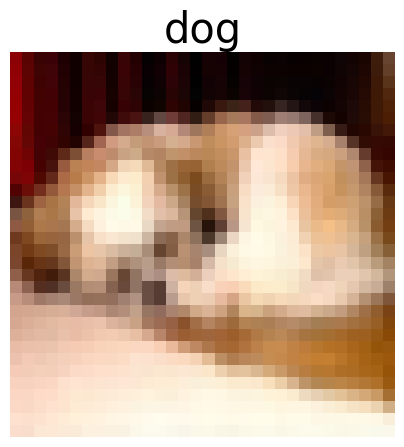

In [86]:
# Grab the image and the label randomly from the batch
images, labels = next(iter(train_loader))
rnd_idx = random.randint(0, train_loader.batch_size - 1)
img = images[rnd_idx]
lbl = labels[rnd_idx]

show(img, lbl)

In [87]:
print(images.shape)  # torch.Size([64, 3, 32, 32])

NUM_CLASSES = 10
IMG_CHANNELS = images.shape[1]
IMG_HEIGHT = images.shape[2]
IMG_WIDTH = images.shape[3]

torch.Size([64, 3, 32, 32])


## Funcciones de entrenamiento

Ahora podemos definir nuestras funciones de entrenamiento. Dado que utilizaremos la precisión para evaluar nuestro modelo, crearemos también una función llamada `get_batch_accuracy` para calcular la precisión.

In [88]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Nuestra función `train` realiza el ciclo completo de entrenamiento. Para cada época, calcula la pérdida de entrenamiento y la precisión, y luego evalúa el modelo en el conjunto de prueba. Finalmente, devuelve el historial de pérdidas de entrenamiento y de prueba para poder graficarlas posteriormente.

In [89]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs, _nombre):

    # Historial para guardar las pérdidas
    historial_loss_train = []
    historial_loss_test = []

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss_acumulada = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:

            # Movemos los datos a la tarjeta gráfica o CPU
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass: predecir y calcular el error (loss)
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)

            # Limpiamos los gradientes del batch anterior
            _optimizer.zero_grad()

            # Backward pass: calcular gradientes
            loss.backward()
            
            # 3. Los pesos de la red se actualizan UNA VEZ por cada mini batch
            _optimizer.step()


            train_loss_acumulada += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoca_loss_train = train_loss_acumulada / len(_train_loader.dataset)
        historial_loss_train.append(epoca_loss_train)

        # Ponemos el modelo en modo evaluación (desactiva Dropout)
        _model.eval()
        test_loss_acumulada = 0.0
        
        # Desactivamos el cálculo de gradientes para ahorrar memoria y ser más rápidos
        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test, y_test = X_test.to(device), y_test.to(device)
                
                # Predecimos con los datos de prueba
                test_outputs = _model(X_test)
                
                # Calculamos la pérdida del batch de prueba y la sumamos
                t_loss = _criterion(test_outputs, y_test)
                test_loss_acumulada += t_loss.item() * X_test.size(0)
                
        # Promedio de pérdida de prueba de la época
        epoch_test_loss = test_loss_acumulada / len(test_loader.dataset)
        historial_loss_test.append(epoch_test_loss)
        
        # Imprimimos el resumen al final de cada época
        iterator.set_postfix(
            train_loss=f"{epoca_loss_train:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
        )


    # --- 4. Curvas de aprendizaje ---
    plt.figure()
    plt.plot(historial_loss_train, label="Train Loss")
    plt.plot(historial_loss_test, label="Test Loss")
    plt.title(_nombre)
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

    return historial_loss_train, historial_loss_test

La función `test` evaluará el modelo con los datos de prueba después de que la red neuronal convolucional haya sido completamente entrenada en PyTorch. Calculará la pérdida promedio y la precisión a través de todo el conjunto de prueba.

In [90]:
def test(_model, _test_loader, _loss_function, _device):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(_device), y.to(_device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### CNN model

Ahora implementemos una arquitectura simple de red neuronal convolucional. Usaremos tres capas convolucionales seguidas de max pooling, y luego un par de capas completamente conectadas antes de la capa de salida, utilizando PyTorch y el conjunto de datos CIFAR-10.

In [91]:
class RedConvolucional(nn.Module):
    def __init__(self, in_channels=IMG_CHANNELS, num_classes=NUM_CLASSES, filtros_base=32, dropout_rate=0.5):
        super().__init__()
        layers = []

        # Calculamos la cantidad de filtros dinámicamente según la base
        f1 = filtros_base
        f2 = f1 * 2
        f3 = f2 * 2

        # Bloque 1
        layers.append(nn.Conv2d(in_channels, f1, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(f1))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(f1, f1, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(f1))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2)) # filtros_base x 16 x 16

        # Bloque 2
        layers.append(nn.Conv2d(f1, f2, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(f2))
        layers.append(nn.ReLU())
        layers.append(nn.Conv2d(f2, f2, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(f2))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2)) # (filtros_base x 2) x 8 x 8
        
        # Bloque 3
        layers.append(nn.Conv2d(f2, f3, kernel_size=3, stride=1, padding=1))
        layers.append(nn.BatchNorm2d(f3))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2)) # (filtros_base x 4) x 4 x 4

         # Clasificador
        layers.append(nn.Flatten())
        layers.append(nn.Linear(f3 * 4 * 4, 256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        layers.append(nn.Linear(256, num_classes)) # CIFAR-10 = 10 clases

        # nn.Sequential agrupa las capas para ejecutarlas en orden
        self.red = nn.Sequential(*layers)

    def forward(self, X):
        return self.red(X)

In [ ]:
# Hiperparámetros de entrenamiento fijos para todos los modelos
LR_CONSTANTE = 0.001
EPOCHS_CONSTANTE = 10

# Configuraciones para los 3 experimentos
experimentos = [
    {
        "nombre": "Modelo 1 (Estándar - Configuración Original)",
        "filtros_base": 32,     # Capacidad media (32->64->128)
        "dropout_rate": 0.5,    # Regularización estándar
        "lr": LR_CONSTANTE,
        "epochs": EPOCHS_CONSTANTE
    },
    {
        "nombre": "Modelo 2 (Pesado - Mayor capacidad para extraer características)",
        "filtros_base": 64,     # Alta capacidad (64->128->256)
        "dropout_rate": 0.6,    # Alta regularización para evitar sobreajuste
        "lr": LR_CONSTANTE,
        "epochs": EPOCHS_CONSTANTE
    },
    {
        "nombre": "Modelo 3 (Ligero - Rápido de entrenar)",
        "filtros_base": 16,     # Menos capacidad (16->32->64)
        "dropout_rate": 0.2,    # Menos regularización
        "lr": LR_CONSTANTE,
        "epochs": EPOCHS_CONSTANTE
    }
]

# Función de pérdida para clasificación multiclase
criterion = nn.CrossEntropyLoss()

Training: 100%|██████████| 10/10 [00:46<00:00,  4.69s/epoch, test_loss=0.5619, train_loss=0.3865]


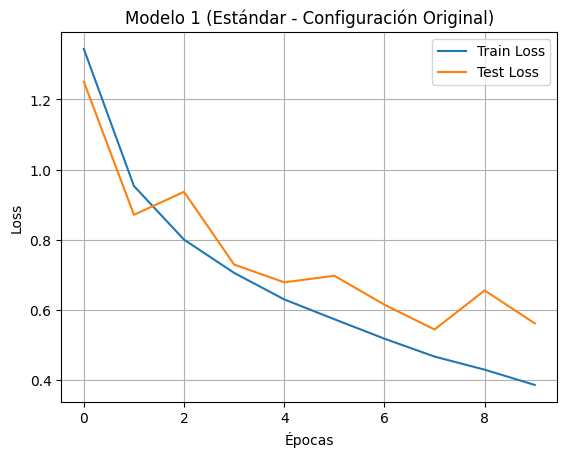

Resultado Final - Modelo 1 (Estándar - Configuración Original):
Test Loss: 0.5619 | Test Accuracy: 82.05%



Training: 100%|██████████| 10/10 [01:25<00:00,  8.60s/epoch, test_loss=0.5754, train_loss=0.5995]


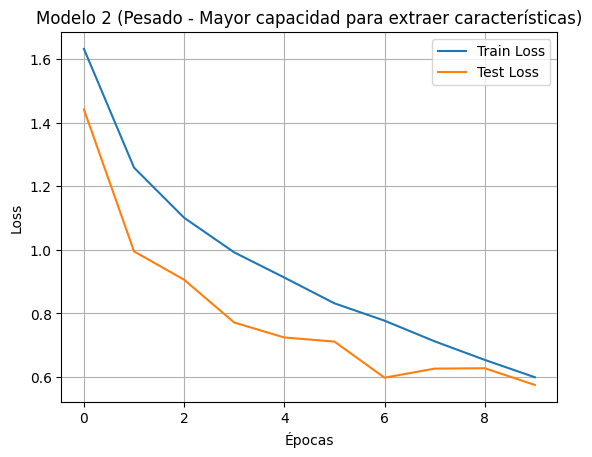

Resultado Final - Modelo 2 (Pesado - Mayor capacidad para extraer características):
Test Loss: 0.5754 | Test Accuracy: 80.82%



Training: 100%|██████████| 10/10 [00:39<00:00,  3.98s/epoch, test_loss=0.6279, train_loss=0.3739]


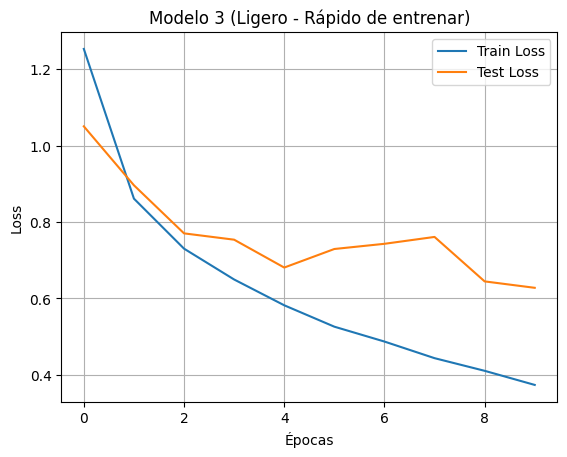

Resultado Final - Modelo 3 (Ligero - Rápido de entrenar):
Test Loss: 0.6279 | Test Accuracy: 80.29%


El mejor modelo es: Modelo 1 (Estándar - Configuración Original) (Test Accuracy: 0.8205)



In [93]:
# Variables para guardar los resultados mejores
mejor_state_dict = None
mejor_acc_global = 0.0
mejor_modelo_nombre = ""


for idx, config in enumerate(experimentos):
    
    # 1. Instanciar Modelo
    model = RedConvolucional(filtros_base=config["filtros_base"], dropout_rate=config["dropout_rate"]).to(device)

    # 2. Definir Optimizador
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    # 3. Entrenar
    historial_loss_train, historial_loss_test = train(model, train_loader, test_loader, criterion, optimizer, config['epochs'], config["nombre"])


    # 4. Evaluar el modelo
    loss_final, acc_final = test(model, test_loader, criterion, device)

    print(f"Resultado Final - {config['nombre']}:")
    print(f"Test Loss: {loss_final:.4f} | Test Accuracy: {acc_final * 100:.2f}%\n")

    if acc_final > mejor_acc_global:
        mejor_acc_global = acc_final
        mejor_modelo_nombre = config['nombre']

        # 5. Guardar el cerebro (los pesos) en `mejor_state_dict`
        mejor_state_dict = model.state_dict()

print(f"\nEl mejor modelo es: {mejor_modelo_nombre} (Test Accuracy: {mejor_acc_global:.4f})\n")



## Clasificar las imágenes arbitrarias proporcionadas

Para clasificar las imágenes ubicadas en `data/images`, primero configuramos la red neuronal convolucional en PyTorch utilizando los mejores hiperparámetros obtenidos durante el entrenamiento (como el número de filtros base y la tasa de *dropout*). Luego, cargamos el `state_dict` correspondiente al modelo con mejor desempeño.

A continuación, empleamos la función `clasificar_imagen_usuario`, la cual se encarga de:
- Cargar cada imagen desde disco y convertirla a formato RGB.
- Aplicar las transformaciones necesarias (reescalado y conversión a tensor).
- Ajustar la dimensión para que sea compatible con el modelo (formato de lote).
- Ejecutar la inferencia en modo evaluación (`eval`) sin cálculo de gradientes.
- Obtener las probabilidades mediante *Softmax* y mostrar las 3 clases más probables.

In [ ]:
def clasificar_imagen_usuario(ruta_imagen, _modelo, _device):
    """
    Recibe la ruta de una imagen en disco, la procesa y utiliza el modelo
    entrenado para regresar la etiqueta textual de la predicción.
    """

    # 1. Configurar el pipeline de preprocesamiento
    transformaciones = transforms.Compose([
        transforms.Resize((IMG_WIDTH, IMG_HEIGHT)),  # Forzar a 32x32 píxeles
        transforms.ToTensor()         # Convertir a Tensor PyTorch y escalar de [0, 255] a [0, 1]
    ])
    
    try:
        # 2. Cargar la imagen
        # Usamos .convert('RGB') por seguridad. Si el usuario sube un PNG con transparencia (RGBA)
        # o una imagen en blanco y negro (L), esto asegura que siempre tenga exactamente 3 canales.
        imagen_pil = Image.open(ruta_imagen).convert('RGB')
    except Exception as e:
        return f"Error al cargar la imagen: {e}"
    
    # 3. Transformar la imagen
    # Al pasar por aquí, la imagen pasa de PIL a un tensor de tamaño [3, 32, 32]
    imagen_tensor = transformaciones(imagen_pil)
    
    # 4. Añadir la dimensión de "Batch" (Lote)
    # Usamos unsqueeze(0) para convertir un formato de imagen [Canales, Alto, Ancho] a [Batch, Canales, Alto, Ancho].
    imagen_batch = imagen_tensor.unsqueeze(0).to(_device)
    
    # 5. Preparar el modelo para inferencia
    _modelo.eval()
    
    # 6. Realizar la predicción sin calcular gradientes (ahorra memoria)
    with torch.no_grad():
        salida = _modelo(imagen_batch)
        
        # Convertimos los logits a porcentajes (0 a 1) usando Softmax
        probabilidades = SoftMax(salida, dim=1)
        
        # Extraemos los 3 valores más altos y sus respectivos índices
        probs_top3, indices_top3 = torch.topk(probabilidades, 3, dim=1)
        
        # Convertimos los tensores a listas de Python para imprimirlos fácilmente
        probs_top3 = probs_top3.squeeze().tolist()
        indices_top3 = indices_top3.squeeze().tolist()
        
        print("Porcentaje de top 3 clases:")
        for i in range(3):
            clase = CLASSES[indices_top3[i]]
            prob = probs_top3[i] * 100
            print(f"{i+1}. {clase.upper()}: {prob:.2f}%")
        
        # La predicción principal sigue siendo el número 1 del Top 3
        indice_prediccion = indices_top3[0]
        
    # Regresar la etiqueta de texto y mostrar la imagen
    etiqueta = CLASSES[indice_prediccion]
    
    # Convertimos un formato a [Canales, Alto, Ancho] y movemos una imagen a CPU para mostrarla
    imagen_cpu = imagen_batch.squeeze(0).cpu()

    show(imagen_cpu, indice_prediccion)

    return etiqueta

Finalmente, la función devuelve la etiqueta predicha para cada imagen, permitiendo evaluar visualmente el rendimiento del modelo entrenado.

Porcentaje de top 3 clases:
1. DOG: 74.15%
2. CAT: 15.81%
3. HORSE: 4.57%


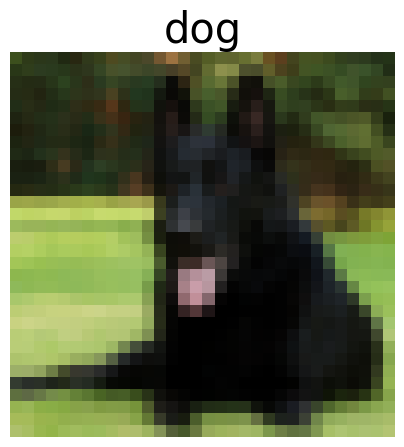


La red neuronal del Modelo 1 (Estándar - Configuración Original) dice que la imagen es un(a): DOG

Porcentaje de top 3 clases:
1. AUTOMOBILE: 100.00%
2. TRUCK: 0.00%
3. SHIP: 0.00%


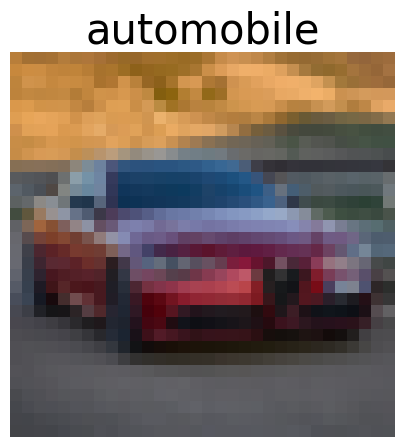


La red neuronal del Modelo 1 (Estándar - Configuración Original) dice que la imagen es un(a): AUTOMOBILE

Porcentaje de top 3 clases:
1. HORSE: 99.94%
2. DEER: 0.03%
3. BIRD: 0.01%


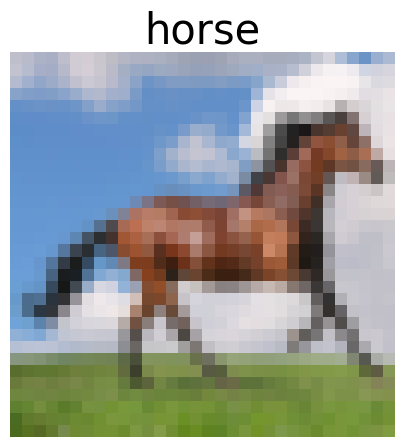


La red neuronal del Modelo 1 (Estándar - Configuración Original) dice que la imagen es un(a): HORSE

Porcentaje de top 3 clases:
1. AIRPLANE: 84.83%
2. BIRD: 8.41%
3. SHIP: 6.44%


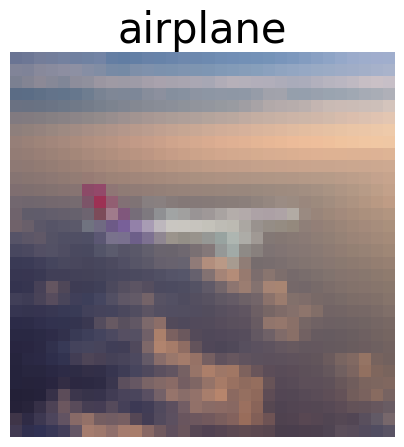


La red neuronal del Modelo 1 (Estándar - Configuración Original) dice que la imagen es un(a): AIRPLANE



In [101]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".gif", ".bmp", ".tiff", ".webp")

# Seleccionar la configuración del mejor modelo
experimentos_dict = {exp["nombre"]: exp for exp in experimentos}
mejor_config = experimentos_dict.get(mejor_modelo_nombre)

# Leer ruta de la carpeta
ruta_imagenes_locales = root + "/images"

model = RedConvolucional(filtros_base=mejor_config["filtros_base"], dropout_rate=mejor_config["dropout_rate"]).to(device)

# Carger el mejor dccionario al modelo
model.load_state_dict(mejor_state_dict)

for img in os.listdir(ruta_imagenes_locales):
    if img.lower().endswith(IMAGE_EXTENSIONS):

        # Poner cada imagen a la ruta
        ruta_imagen = ruta_imagenes_locales + "/" + img

        # Usamos la variable 'modelo' de tu último ciclo de entrenamiento como placeholder
        etiqueta_predicha = clasificar_imagen_usuario(ruta_imagen, model, device) 

        print(f"\nLa red neuronal del {mejor_modelo_nombre} dice que la imagen es un(a): {etiqueta_predicha.upper()}\n")

## Reflection

En esta actividad, realicé la transición del reconocimiento de señas al dataset CIFAR-10, el cual presenta un nivel de complejidad mayor al trabajar con 60,000 imágenes a color (RGB) de 32x32 píxeles. El objetivo principal fue implementar y comparar una Red Neuronal Convolucional (CNN) a través de tres experimentos con distintos hiperparámetros para clasificar 10 categorías de objetos cotidianos.

Lo más interesante fue integrar conocimientos previos de los notebooks *3.neural_networks.ipynb*, estructuras básicas de red neuronal, y *5.cnn.ipynb*, capas convolucionales. El desafío técnico no solo radicó en el cambio de dimensiones de los datos, sino en adaptar las funciones de carga de PyTorch para procesar tres canales de color en lugar de uno solo. Esto me permitió entender cómo la arquitectura de la red debe ajustarse para extraer características más ricas de las imágenes.

Gracias a este ejercicio, he dominado herramientas de PyTorch que serán fundamentales para mi proyecto personal, especialmente en el manejo eficiente de batches y la normalización de tensores. El siguiente paso será analizar cuál de los tres experimentos de hiperparámetros ofreció la mejor precisión para aplicar esa configuración en modelos de visión artificial más avanzados.